<a href="https://colab.research.google.com/github/lauraaguilargonzalez18/estadisticaverano2026/blob/main/HRSESTUDIO/horas_estudiadas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Planteamiento del problema
En la actualidad, diversos factores pueden influir en el rendimiento académico de los estudiantes. Entre ellos se encuentran el tiempo dedicado al uso del celular, la cantidad de materias cursadas, las horas de estudio, las horas de sueño y la asistencia a clases.

Sin embargo, no siempre es evidente cuáles de estas variables tienen una mayor relación con las calificaciones obtenidas.
Por ello, se realizó una recopilación de datos de un grupo de estudiantes con el objetivo de analizar la posible correlación entre estos factores y su desempeño académico. La información recolectada incluye el número de horas diarias de uso del celular, la cantidad de materias inscritas, las horas de estudio, las horas de sueño, el porcentaje de asistencia y la calificación final obtenida.
A partir de estos datos, se busca responder preguntas como:

¿Existe una relación entre el uso del celular y las calificaciones?

¿Las horas de estudio influyen positivamente en el desempeño académico?

¿La asistencia y el descanso están asociados con mejores resultados escolares?

¿Cuál de las variables analizadas presenta la mayor correlación con la calificación final?

La siguiente tabla presenta los datos recopilados para realizar el análisis estadístico y la evaluación de las posibles correlaciones entre las variables estudiadas

In [ ]:

import pandas as pd

datos = {
    'Alumno': ['Jocelyn', 'Agustín', 'Nathali', 'Laura', 'Carlos',
               'Mariana', 'Diego', 'Fernanda', 'Sofía', 'Ricardo',
               'Valeria', 'Emiliano', 'Camila', 'José', 'Paola', 'Daniel'],

    'Horas_cel': [5, 6, 5, 7, 4, 3, 8, 6, 5, 7, 4, 6, 3, 8, 5, 4],

    'Materias': [6, 7, 7, 5, 6, 5, 7, 6, 5, 8, 7, 6, 6, 5, 8, 7],

    'Horas_estudio': [3, 1, 2, 4, 3, 5, 1, 2, 4, 1, 3, 2, 5, 1, 2, 4],

    'Horas_sueno': [8, 6, 7, 8, 7, 8, 6, 7, 8, 5, 7, 7, 8, 6, 7, 8],

    'Asistencia': [95, 85, 90, 98, 92, 100, 80, 88, 97, 78, 93, 89, 99, 82, 87, 96],

    'Calificacion': [9, 6, 8, 9, 8, 10, 6, 7, 9, 5, 8, 7, 10, 6, 7, 9]
}

df = pd.DataFrame(datos)

# Mostrar tabla
display(df)


,Alumno,Horas_cel,Materias,Horas_estudio,Horas_sueno,Asistencia,Calificacion
0,Jocelyn,5,6,3,8,95,9
1,Agustín,6,7,1,6,85,6
2,Nathali,5,7,2,7,90,8
3,Laura,7,5,4,8,98,9
4,Carlos,4,6,3,7,92,8
5,Mariana,3,5,5,8,100,10
6,Diego,8,7,1,6,80,6
7,Fernanda,6,6,2,7,88,7
8,Sofía,5,5,4,8,97,9
9,Ricardo,7,8,1,5,78,5


In [ ]:
df.rename(columns={
 "Horas_cel":"Calificacion"
},inplace=True)

In [ ]:
X=df["Horas_estudio"]#variable independiente
Y=df["Calificacion"]# variable dependiente

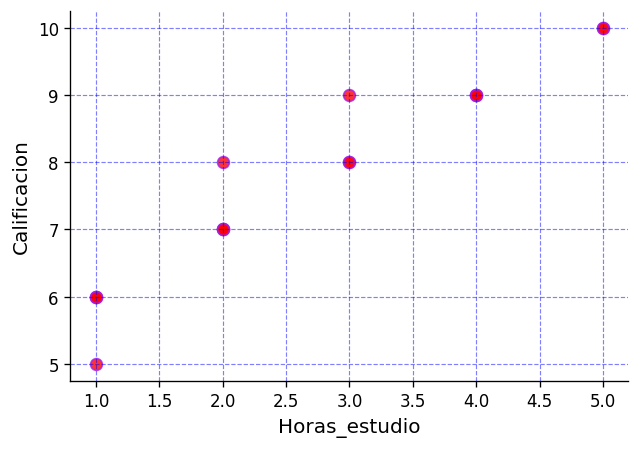

In [ ]:
# Importamos la librería matplotlib.pyplot y le damos el pseudónimo plt
import matplotlib.pyplot as plt

# Configuración general del gráfico
plt.figure(
    figsize=(6, 4),   # tamaño de la figura (ancho, alto) en pulgadas
    dpi=120           # resolución del gráfico
)

# Fix: Ensure Y is a single Series by selecting the appropriate column
# The 'Y' variable currently holds a DataFrame with two 'Calificacion' columns due to a previous rename operation.
# The second column (index 1) corresponds to the original 'Calificacion' data.
Y = Y.iloc[:, 1]

# Gráfico de dispersión
plt.scatter(
    X, Y,
    marker="o",       # forma: googlear "matplotlib.markers"
    color="red",     # color de los puntos
    edgecolor='#A020F0',    # borde de los puntos
    alpha=0.8,            # transparencia: 0 es invisible y 1 es color sólido
    s=50,                 # tamaño de los puntos
)

# Etiquetas de los ejes
# eje x
plt.xlabel(
    'Horas_estudio', # etiqueta del eje x
    fontsize=12  # tamaño de fuente
)

plt.ylabel(
    'Calificacion', # etiqueta del eje y
    fontsize=12 # tamaño de fuente
)

# Fuente de los ticks
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

# Márgenes
plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior

# Cuadrícula (opcional, pero didáctica)
plt.grid(
    visible=True,
    linestyle='--',
    linewidth=0.7,
    alpha=0.5,
    color="blue"
)

In [ ]:
# Importar la función pearsonr desde scipy.stats
from scipy.stats import pearsonr

# Test de Pearson
# H0: rho = 0     (No hay correlación)
# H1: rho ≠ 0     (Sí hay correlación)
# alpha = 0.05

r, valor_p = pearsonr(X, Y)

print(f"Coeficiente de correlación: {r: 0.4f}")
print(f'valor_p: {valor_p: 0.4f}')

Coeficiente de correlación:  0.9580
valor_p:  0.0000


In [ ]:
import statsmodels.api as sm
x_constante = sm.add_constant(X)
modelo = sm.OLS(Y, x_constante) . fit()
Y_calculada = modelo.predict(x_constante)

In [ ]:
# Coeficiente de determinacion
from sklearn.metrics import r2_score

r2 = r2_score(Y, Y_calculada)

print(f"Coeficiente de determinacion: {r2: 0.2%}")

Coeficiente de determinacion:  91.77%


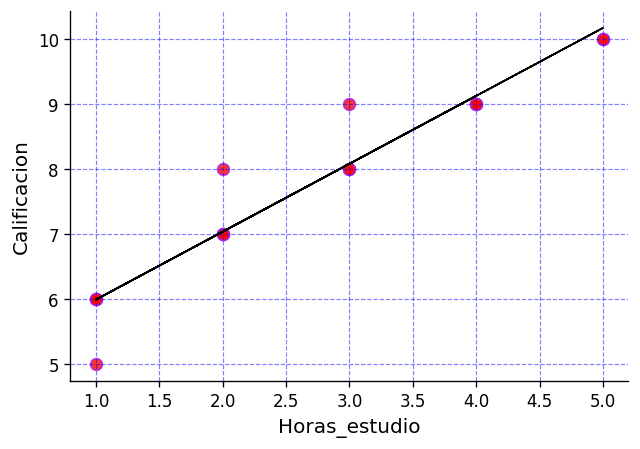

In [ ]:
# Importamos la librería matplotlib.pyplot y le damos el pseudónimo plt
import matplotlib.pyplot as plt

# Configuración general del gráfico
plt.figure(
    figsize=(6, 4),   # tamaño de la figura (ancho, alto) en pulgadas
    dpi=120           # resolución del gráfico
)

# Gráfico de dispersión
plt.scatter(
    X, Y,
    marker="o",       # forma: googlear "matplotlib.markers"
    color="red",     # color de los puntos
    edgecolor='#A020F0',    # borde de los puntos
    alpha=0.8,            # transparencia: 0 es invisible y 1 es color sólido
    s=50,                 # tamaño de los puntos
)

# Grafico de linea
plt.plot(
    X, Y_calculada,
    color='black', #color de la linea
    linewidth=1.0,     #grosor de la linea
    linestyle='--',      #estilo de la linea
    label='Recta de Regresion'
)
# Etiquetas de los ejes
# eje x
plt.xlabel(
    'Horas_estudio', # etiqueta del eje x
    fontsize=12  # tamaño de fuente
)

plt.ylabel(
    'Calificacion', # etiqueta del eje y
    fontsize=12 # tamaño de fuente
)

# Fuente de los ticks
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

# Márgenes
plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior

# Cuadrícula (opcional, pero didáctica)
plt.grid(
    visible=True,
    linestyle='--',
    linewidth=0.7,
    alpha=0.5,
    color="blue"
)

In [ ]:
residuales = modelo.resid

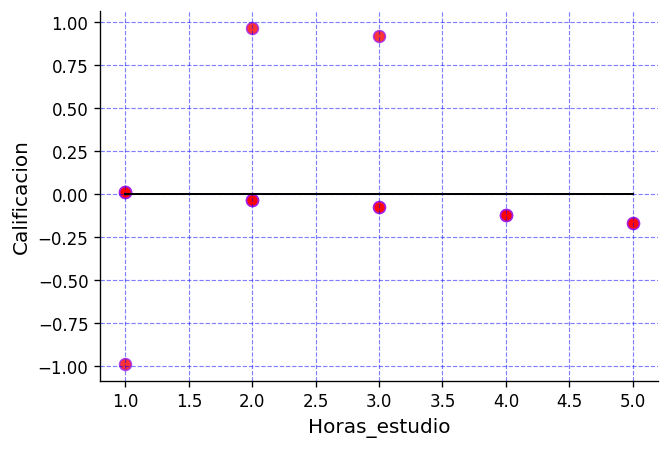

In [ ]:
# Importamos la librería matplotlib.pyplot y le damos el pseudónimo plt
import matplotlib.pyplot as plt

# Configuración general del gráfico
plt.figure(
    figsize=(6, 4),   # tamaño de la figura (ancho, alto) en pulgadas
    dpi=120           # resolución del gráfico
)

# Gráfico de dispersión
plt.scatter(
    X,residuales,      # <---------------------------------------------------------
    marker="o",       # forma: googlear "matplotlib.markers"
    color="red",     # color de los puntos
    edgecolor='#A020F0',    # borde de los puntos
    alpha=0.8,            # transparencia: 0 es invisible y 1 es color sólido
    s=50,                 # tamaño de los puntos
)

# Grafico de linea
plt.plot(
    X, Y_calculada * 0,# <---------------------------------------------------------
    color='black', #color de la linea
    linewidth=1.0,     #grosor de la linea
    linestyle='--',      #estilo de la linea
    label='Recta de Regresion'
)
# Etiquetas de los ejes
# eje x
plt.xlabel(
    'Horas_estudio', # etiqueta del eje x
    fontsize=12  # tamaño de fuente
)

plt.ylabel(
    'Calificacion', # etiqueta del eje y #<-----------------------------------------
    fontsize=12 # tamaño de fuente
)

# Fuente de los ticks
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

# Márgenes
plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior

# Cuadrícula (opcional, pero didáctica)
plt.grid(
    visible=True,
    linestyle='--',
    linewidth=0.7,
    alpha=0.5,
    color="blue"
)

In [ ]:
modelo.params

,0
const,4.942675
Horas_estudio,1.044586


valor-p (Shapiro) = 0.00037258678857548556


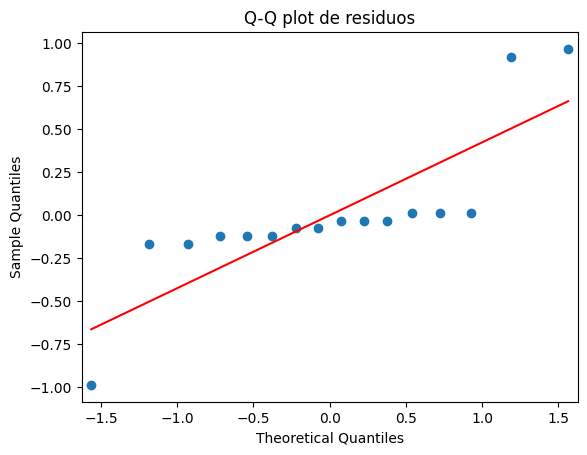

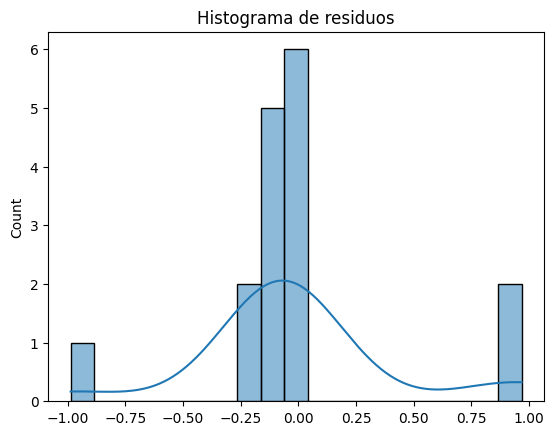

In [ ]:
from scipy.stats import shapiro
import matplotlib.pyplot as plt
import seaborn as sns

#test de shapiro-Wilk
# H0: Hay normalidad
# H1: No hay normalidad

# Prueba de Shapiro-Wilk
stat, valor_p_sh = shapiro(residuales)
print(f"valor-p (Shapiro) = {valor_p_sh}")

# Visualización: Q-Q plot
sm.qqplot(residuales, line='s')
plt.title("Q-Q plot de residuos")
plt.show()

# Histograma
sns.histplot(residuales, kde=True)
plt.title("Histograma de residuos")
plt.show()

In [ ]:
# Test de Breusch-Pagan
# H0: No hay heterocedasticidad (dispersión es igual en toda la recta)
# H1: Hay Heterocedasticidad (dispersión distinta a lo largo de la recta)
# alpha = 0.05

from statsmodels.stats.api import het_breuschpagan
import statsmodels.api as sm
_, valor_p_bp, _, _ = het_breuschpagan(residuales, x_constante)
print(f'valor-p de Breusch-Pagan: {valor_p_bp: 0.4f}\n')

valor-p de Breusch-Pagan:  0.3430



In [ ]:
# test de ANOVA (Analysis of Variance)
# H0: beta_1 = 0   (No hay correlación)
# H1: beta_1 ≠ 0   (Sí hay correlación)

import statsmodels.api as sm
from statsmodels.formula.api import ols
import pandas as pd

# Create a temporary DataFrame with the correct 'Horas_estudio' and 'Calificacion' Series
# This avoids the ambiguity caused by duplicate 'Calificacion' column names in the original 'df'.
temp_df = pd.DataFrame({'Horas_estudio': X, 'Calificacion': Y})

# Y ~ X
modelo_lineal = ols(
    '''Calificacion ~ Horas_estudio''',
    data = temp_df).fit()
tabla_anova = sm.stats.anova_lm(modelo_lineal)
tabla_anova

,df,sum_sq,mean_sq,F,PR(>F)
Horas_estudio,1.0,32.121019,32.121019,156.199115,5.540615e-09
Residual,14.0,2.878981,0.205641,NaN,NaN


In [ ]:
modelo.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:           Calificacion   R-squared:                       0.918
Model:                            OLS   Adj. R-squared:                  0.912
Method:                 Least Squares   F-statistic:                     156.2
Date:                Fri, 03 Jul 2026   Prob (F-statistic):           5.54e-09
Time:                        04:41:31   Log-Likelihood:                -8.9818
No. Observations:                  16   AIC:                             21.96
Df Residuals:                      14   BIC:                             23.51
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
=================================================================================
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const             4.9427      0.252     19.644      0.000       4.403       5.482
Horas_estudio     1.0446      0.084     12.498      0.000       0.865       1.224
==============================================================================
Omnibus:                        6.047   Durbin-Watson:                   1.605
Prob(Omnibus):                  0.049   Jarque-Bera (JB):                3.426
Skew:                           0.588   Prob(JB):                        0.180
Kurtosis:                       4.939   Cond. No.                         7.28
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""